In [5]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # only expose one GPU to PyTorch
sys.path.insert(0, "/workspace/Hyperspectral_Coolstuff/hyperspecrtral_encoder_proj")
from hsi_models_v4_1 import load_band_stats, load_emit_wavelengths_nm, estimate_band_stats_parallel, save_band_stats, EmitRadDataset, recon_loss, HyperspectralAutoencoder, class_loss, do_classification


import numpy as np
import glob
import random
import gc
import time

from datetime import datetime
import multiprocessing as mp

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoConfig, AutoProcessor, Qwen3VLForConditionalGeneration
import torch.fft

qwen_name = "Qwen/Qwen3-VL-2B-Instruct"
hidden_size = AutoConfig.from_pretrained(qwen_name).text_config.hidden_size
print("Qwen hidden_size:", hidden_size)

torch.cuda.empty_cache()
print(torch.cuda.memory_allocated())

import matplotlib
print(matplotlib.get_backend())
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Qwen hidden_size: 2048
0
module://matplotlib_inline.backend_inline


In [6]:
## Get Paths and Stats for dataset + divide into train/val
BAND_STATS_PATH = "emit_band_stats.npz" 
INSTRUMENT_PATH = "instrument.json"
RECOMPUTE_STATS = False

FILL = -9999.0
BANDS = 285
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)

# # Get saved old-format hyperspectral chips:
# RAD_DIRS = ["/dataset/CSE290D_F25/data/emit_dataset/chips/ch4_plume",
#             "/dataset/CSE290D_F25/data/emit_dataset/chips/no_plume",]
# rad_files = []
# for RAD_DIR in RAD_DIRS:
#     rad_files.extend(sorted(glob.glob(f"{RAD_DIR}/*RAD*l1b*.npy")))
# print("RAD files:", len(rad_files))

# Get new-format hyperspectral chips:
#dataset_dir = "/more_data/emit_dataset_2/"
dataset_dir = "/root/emit_data/"
chip_path_list = sorted(glob.glob(f"{dataset_dir}/*/*/hypercube.npy"))
rad_files = chip_path_list

rad_files_shuf = rad_files.copy()
random.shuffle(rad_files_shuf)

n_val = max(1, int(0.1 * len(rad_files_shuf)))
val_files = rad_files_shuf[:n_val]
train_files = rad_files_shuf[n_val:]
print("train:", len(train_files), "val:", len(val_files))


if (not RECOMPUTE_STATS) and os.path.exists(BAND_STATS_PATH):
    print(f"Loading band stats from: {BAND_STATS_PATH}")
    band_mean, band_std, band_cnt, wavelengths_nm = load_band_stats(BAND_STATS_PATH)
    if wavelengths_nm is None:
        wavelengths_nm = load_emit_wavelengths_nm(INSTRUMENT_PATH, expected_bands=BANDS)
else:
    print("Computing band stats...")
    band_mean, band_std, band_cnt = estimate_band_stats_parallel(train_files, max_files=len(train_files), num_workers=16)
    wavelengths_nm = load_emit_wavelengths_nm(INSTRUMENT_PATH, expected_bands=BANDS)
    print(f"Saving band stats to: {BAND_STATS_PATH}")
    save_band_stats(
        BAND_STATS_PATH,
        band_mean,
        band_std,
        band_cnt,
        wavelengths_nm=wavelengths_nm,
        fill=FILL,
        bands=BANDS,
        n_files=len(train_files),
    )

print("mean/std (first 5):", band_mean[:5], band_std[:5])
if band_cnt is not None:
    print("valid pixels per band (min/median/max):", band_cnt.min(), np.median(band_cnt), band_cnt.max())
    


train: 0 val: 0
Loading band stats from: emit_band_stats.npz
mean/std (first 5): [4.9108047 4.680414  5.2371535 7.382016  7.4158936] [1.0328723 1.0213631 1.1832882 1.7161906 1.7839403]
valid pixels per band (min/median/max): 53040802 53040802.0 53040802


In [3]:
def show_fft_comparison(ds, model, idx=0, n=80, device="cuda:0"):
    device = torch.device(device)
    model = model.to(device).eval()

    x, valid, label = ds[idx]  # (C,H,W)
    
    # --- 1. Run Inference ---
    with torch.inference_mode():
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=(device.type=="cuda")):
            # Add batch dim -> (1, C, H, W)
            y, _ = model(x.unsqueeze(0).to(device, non_blocking=True))
        if device.type == "cuda":
            torch.cuda.synchronize()

    # --- 2. Prepare Tensors ---
    x_hat = y.squeeze(0).float().cpu()
    x = x.float().cpu()
    valid = valid.float().cpu()

    # Mask data to ensure invalid regions (zeros) don't distort the FFT
    x_masked = x * valid
    x_hat_masked = x_hat * valid

    # --- 3. Compute Zonal Power Spectrum ---
    # FFT along Longitude (dim=-1), output is complex
    fft_x = torch.fft.rfft(x_masked, n=n, dim=-1, norm="ortho")       # (C, H, W_freq)
    fft_hat = torch.fft.rfft(x_hat_masked, n=n, dim=-1, norm="ortho") # (C, H, W_freq)

    # Compute Power (Magnitude Squared)
    pow_x = fft_x.abs() ** 2
    pow_hat = fft_hat.abs() ** 2

    # Average over Latitude (dim=-2) and then Bands (dim=0)
    # Result is a 1D curve representing global spectral quality
    spec_x = pow_x.mean(dim=(0, -2)).numpy()
    spec_hat = pow_hat.mean(dim=(0, -2)).numpy()

    # --- 4. Plot ---
    wavenumbers = np.arange(len(spec_x))
    
    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    
    # Use semilogy for power spectra
    ax.semilogy(wavenumbers, spec_x, label='Input (Truth)', color='black', linewidth=1.5, alpha=0.8)
    ax.semilogy(wavenumbers, spec_hat, label='Reconstruction', color='red', linestyle='--', linewidth=1.5)
    
    ax.set_title(f"FFT Reconstruction Analysis (idx {idx})")
    ax.set_xlabel("Wavenumber (Spatial Frequency)")
    ax.set_ylabel("Power (Log Scale)")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)
    
    # Add helper text for interpretation
    ax.text(0.02, 0.05, "Large Scale\nStructures", transform=ax.transAxes, fontsize=8, color='gray')
    ax.text(0.98, 0.05, "Fine Scale\nDetails", transform=ax.transAxes, fontsize=8, color='gray', ha='right')

    plt.tight_layout()
    plt.show()

def show_recon_band(ds, model, idx=0, band=0, device="cuda:0"):
    device = torch.device(device)
    model = model.to(device).eval()

    x, valid, label = ds[idx]  # (C,H,W)
    with torch.inference_mode():
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=(device.type=="cuda")):
            y, _ = model(x.unsqueeze(0).to(device, non_blocking=True))
        if device.type == "cuda":
            torch.cuda.synchronize()

    x_hat = y.squeeze(0).float().cpu()
    x = x.float().cpu()
    valid = valid.cpu()

    xin = x[band].numpy()
    xre = x_hat[band].numpy()
    m = valid[band].numpy().astype(bool)

    if m.any():
        vmin = float(xin[m].min())
        vmax = float(xin[m].max() + 1e-6)
    else:
        vmin, vmax = 0.0, 1.0

    fig, ax = plt.subplots(1, 3, figsize=(10, 4))
    ax[0].imshow(xin, cmap="gray", vmin=vmin, vmax=vmax)
    ax[0].set_title(f"Input (band {band})")
    ax[0].axis("off")

    ax[1].imshow(xre, cmap="gray", vmin=vmin, vmax=vmax)
    ax[1].set_title(f"Recon (band {band})")
    ax[1].axis("off")

    ax[2].imshow(xre, cmap="gray", vmin=np.min(xre), vmax=np.max(xre))
    ax[2].set_title(f"Recon, self-norm (band {band})")
    ax[2].axis("off")

    plt.show()
    
def show_recon_slice(ds, model, idx=0, row=0, device="cuda:0"):
    device = torch.device(device)
    model = model.to(device).eval()

    x, valid, label = ds[idx]  # (C,H,W)
    with torch.inference_mode():
        with torch.autocast(device_type="cuda", dtype=torch.bfloat16, enabled=(device.type=="cuda")):
            y, _ = model(x.unsqueeze(0).to(device, non_blocking=True))
        if device.type == "cuda":
            torch.cuda.synchronize()

    x_hat = y.squeeze(0).float().cpu()
    x = x.float().cpu()
    valid = valid.cpu()

    # Slice a spatial row to get (spectral x spatial) = (C, W)
    xin = x[:, row, :].numpy()
    xre = x_hat[:, row, :].numpy()
    m = valid[:, row, :].numpy().astype(bool)

    if m.any():
        vmin = float(xin[m].min())
        vmax = float(xin[m].max() + 1e-6)
    else:
        vmin, vmax = 0.0, 1.0

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(xin, cmap="gray", vmin=vmin, vmax=vmax, aspect="auto")
    ax[0].set_title(f"Input (row {row})")
    ax[0].set_xlabel("Spatial (W)")
    ax[0].set_ylabel("Spectral (bands)")
    ax[0].axis("off")

    ax[1].imshow(xre, cmap="gray", vmin=vmin, vmax=vmax, aspect="auto")
    ax[1].set_title(f"Recon (row {row})")
    ax[1].set_xlabel("Spatial (W)")
    ax[1].set_ylabel("Spectral (bands)")
    ax[1].axis("off")
    plt.show()


In [ ]:
model_dir = "/more_data/models/v4.1/"
os.makedirs(model_dir, exist_ok=True)

model_checkpoint_path = "hs_autoencoder_latest.pt" #None #os.path.join(model_dir, "hs_autoencoder_best_v4.0_ps16x16x15_overlapTrue_True_overNoneqx1024d_20260209_074128_3e-05-3e-07_val_loss_3.330000_totalepochs_10.pt")

batch_size = 1    # 2 -> 11GB (2080Ti Limit), 8 -> 13GB??, 16 -> 21GB (A10 limit)
num_epochs = 128
batches_per_epoch = 256#256
batches_per_val = 128
cosine_annealing_cycle_length_in_batches = 2048  #matching this to batches_per_epoch works nicely
max_lr = 1e-6   #v4.0 model collapses at 3e-5
min_lr = 1e-8

patch_size_spatial = 16
patch_size_spectral = 15
decoder_input_channels = 1024
num_spectral_queries = None
depth = 6
num_heads = 8
mlp_ratio = 2.0
do_query_summarization = False #Note: If False, will use a lot more VRAM due to increased number of tokens.  Compensate by increasing patch sizes
overlap_patches_spatial = True
overlap_patches_spectral = True

model_save_path = os.path.join(model_dir, f"hs_autoencoder_best_v4.0_ps{patch_size_spatial}x{patch_size_spatial}x{patch_size_spectral}_overlap{overlap_patches_spatial}_{overlap_patches_spectral}_over{num_spectral_queries}qx{decoder_input_channels}d_{datetime.now().strftime('%Y%m%d_%H%M%S')}_{max_lr}-{min_lr}.pt")

# Loss Weights relative to MSE.  MSE pushes image towards the ground truth, but risk-averse and can collapse to mean
l_alpha = 2.0  # Spectral Derivative Loss.  Pushes spectral dimension towards smoother transitions between bands, 
               # ... could delete subtle signals like plumes however.
l_beta = 5.0   # Spatial Variance Loss.  Fights MSE's blurring effect to introduce texture and noise
l_gamma = 0.05 # Spectral Angle "SAM" Loss.  Encourages pushing the spectra towards ground truth, 
               # ... but could deteriorate spatial mixing, creating blobs of specific spectral types and erasing texture.
l_delta = 0  # Query Orthogonality Loss.  Encourages spectral queries to be distinct.  Without this, 
               # ... the model can collapse into similar queries and erase spectral variability.
l_theta = 1.5 # FFT Loss.  Encourages the model to focus on finer details

loss_fft_wavenum_start = 5
loss_fft_wavenum_end = 15

l_class = 1.5 # Weight for the binary classifier

## Tests:
#alpha=0.1, beta=0.1, gamma=0.5, delta=0.1  Results in blobby, paint-by-numbers style result.
#alpha=2.0, beta=5.0, gamma=0.05, delta=1.0  Getting better reconstructions, but still blurry, and missing a lot of spectral detail.  High Beta helps to prevent model collapse at the beginning of training.

# =================================================================
# Component    | Raw Avg    | Weight   | Weighted   | % Total
# -----------------------------------------------------------------
# l_mse        | 0.303679   | 1        | 0.303679   |   51.1%
# l_deriv      | 0.017019   | 2        | 0.034037   |    5.7%
# l_sam        | 0.642541   | 0.2      | 0.128508   |   21.6%
# l_spatial    | 0.054251   | 1        | 0.054251   |    9.1%
# l_ortho      | 0.000001   | 100      | 0.000108   |    0.0%
# l_fft        | 0.074049   | 1        | 0.074049   |   12.5%
# -----------------------------------------------------------------
# TOTAL        | -          | -        | 0.594632   |  100.0%
# =================================================================
# RESULT:  Starting to look paint-by-numberish, surreal blobby again


# =================================================================
# Component    | Raw Avg    | Weight   | Weighted   | % Total
# -----------------------------------------------------------------
# l_mse        | 0.311450   | 1        | 0.311450   |   51.4%
# l_deriv      | 0.017309   | 2        | 0.034617   |    5.7%
# l_sam        | 0.646689   | 0.1      | 0.064669   |   10.7%
# l_spatial    | 0.054123   | 1        | 0.054123   |    8.9%
# l_ortho      | 0.000000   | 1000     | 0.000002   |    0.0%
# l_fft        | 0.070263   | 2        | 0.140526   |   23.2%
# -----------------------------------------------------------------
# TOTAL        | -          | -        | 0.605389   |  100.0%
# =================================================================
# Result: Still paint by numbery blobby surreal

In [5]:


#Intentional overfit to verify training works
# train_files_overfit = [train_files[0] for _ in range(64)]
# val_files_overfit   = [val_files[0]   for _ in range(64)]

train_ds = EmitRadDataset(train_files, band_mean, band_std, fill=FILL)
val_ds   = EmitRadDataset(val_files,   band_mean, band_std, fill=FILL)

train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,           # try 4, 8, or 12 depending on CPU/disk
    # pin_memory=False,         # false to prevent memory issues
    # persistent_workers=True, # keep workers alive across epochs
    # prefetch_factor=1,       # batches prefetched per worker (default 2)
)

val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    # pin_memory=False,
    # persistent_workers=True,
    # prefetch_factor=1,
)

# model
qwen_name = "Qwen/Qwen3-VL-2B-Instruct"
hidden_size = AutoConfig.from_pretrained(qwen_name).text_config.hidden_size
print("Qwen hidden_size:", hidden_size)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = HyperspectralAutoencoder(
    embed_dim=hidden_size,
    num_bands=285,
    patch_size_spatial=patch_size_spatial,
    patch_size_spectral=patch_size_spectral,
    decoder_input_channels=decoder_input_channels,
    num_spectral_queries=num_spectral_queries,
    depth=depth,
    num_heads=num_heads,
    do_query_summarization=do_query_summarization,
    mlp_ratio=mlp_ratio,   #Default is 4.0, reduced to 2.0 for memory efficiency
                     # ... with this at 4 and batch size 8, 14.3GB VRAM used
    overlap_patches_spatial=overlap_patches_spatial,
    overlap_patches_spectral=overlap_patches_spectral
).to(device)#.cuda()#.to(torch.bfloat16)

opt = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=0.001)
# # Single-cycle cosine annealing scheduler
# sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cosine_annealing_cycle_length_in_batches)
sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    opt,
    T_0=cosine_annealing_cycle_length_in_batches,    # steps in the first cycle
    T_mult=1,         # keep all cycles same length; set >1 to grow cycle length
    eta_min=min_lr,     # minimum lr at the bottom of the cosine
)

best_val = float("inf")
starting_epoch = 0
if model_checkpoint_path is not None and os.path.exists(model_checkpoint_path):
    print(f"Loading checkpoint: {model_checkpoint_path}")
    ckpt = torch.load(model_checkpoint_path, map_location="cpu", weights_only=False)
    if isinstance(ckpt, tuple):
        ckpt = ckpt[0]
        
    sd = ckpt["model_state_dict"]
    
    # 1. Strip 'module.' (DataParallel)
    if len(sd) > 0 and next(iter(sd.keys())).startswith("module."):
        print(" > Stripping 'module.' prefix from state_dict keys")
        sd = {k[len("module."):]: v for k, v in sd.items()}

    # 2. Strip '_orig_mod.' (torch.compile)
    if len(sd) > 0 and next(iter(sd.keys())).startswith("_orig_mod."):
        print(" > Stripping '_orig_mod.' prefix from state_dict keys")
        sd = {k[len("_orig_mod."):]: v for k, v in sd.items()}

    model.load_state_dict(sd, strict=True)

    # optional: resume optimizer/scheduler/step if present in the checkpoint
    if "opt_state_dict" in ckpt:
        opt.load_state_dict(ckpt["opt_state_dict"])
    # if "sched_state_dict" in ckpt:
    #     sched.load_state_dict(ckpt["sched_state_dict"])
    best_val = float(ckpt.get("best_val", best_val))
    starting_epoch = int(ckpt.get("epoch", starting_epoch))
    
    del ckpt
    del sd
    torch.cuda.empty_cache()

    print(f"Resumed: best_val={best_val:.6f}")
    best_val = float("inf")
else:
    print(f"No checkpoint found at {model_checkpoint_path}; training from scratch.")

model = torch.compile(model)


Qwen hidden_size: 2048
No checkpoint found at None; training from scratch.


/dataset/CSE290D_F25/transformer_head_work/hsi_models_v4_1.py:565: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  x = torch.from_numpy(x).permute(2, 0, 1)  # (B,H,W)


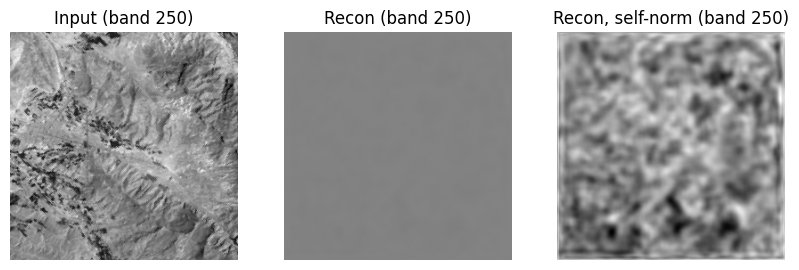

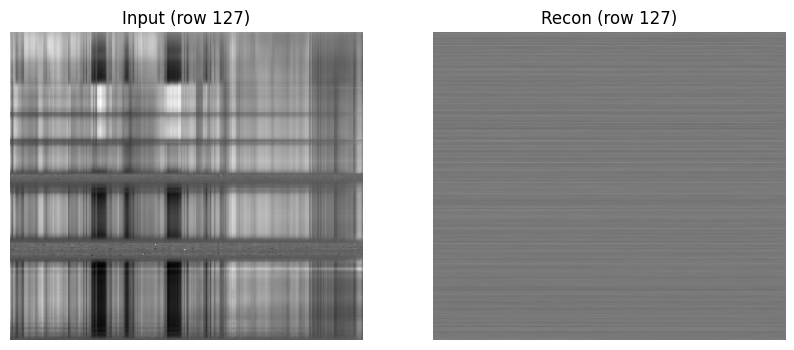

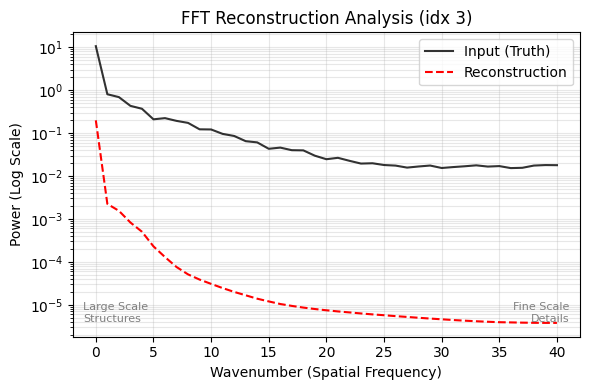

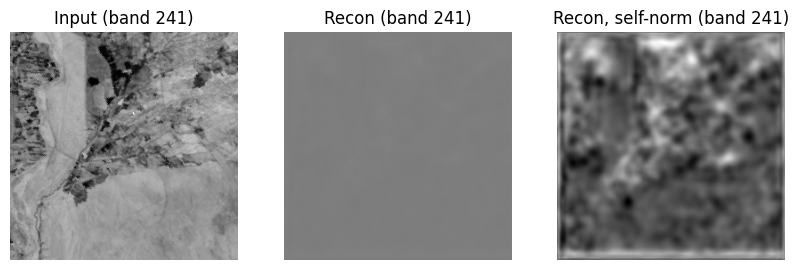

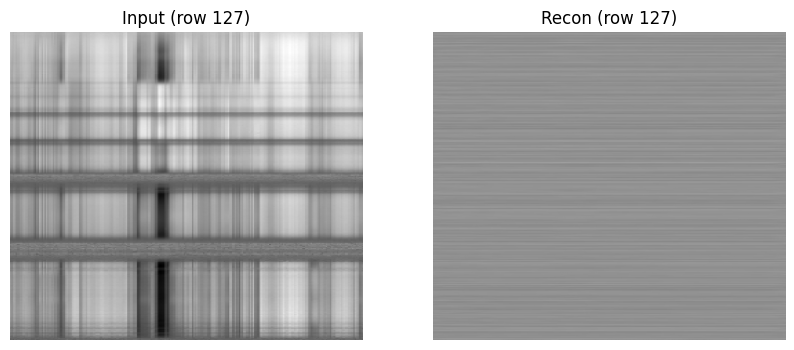

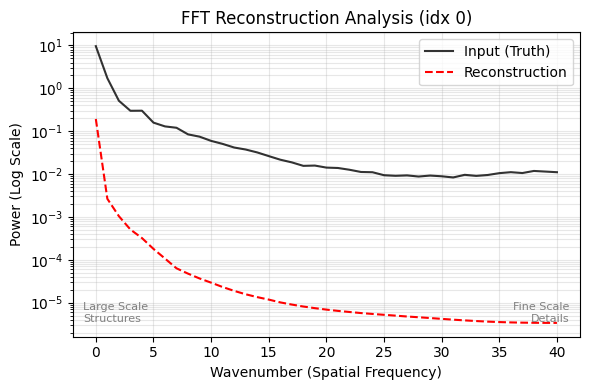

In [6]:
show_recon_band(val_ds, model, idx=3, band=250, device="cuda:0")
show_recon_slice(val_ds, model, idx=3, row=127, device="cuda:0")
show_fft_comparison(val_ds, model, idx=3, n=80, device="cuda:0")

show_recon_band(train_ds, model, idx=0, band=241, device="cuda:0")
show_recon_slice(train_ds, model, idx=0, row=127, device="cuda:0")
show_fft_comparison(train_ds, model, idx=0, n=80, device="cuda:0")


epoch 000 batch 00000 of 256 train_loss 1.461455 smoothed_loss 1.461455 lr 1.00e-06 time elapsed 30s ETA 7727s
epoch 000 batch 00032 of 256 train_loss 3.279944 smoothed_loss 4.823891 lr 9.99e-07 time elapsed 137s ETA 927s
epoch 000 batch 00064 of 256 train_loss 1.195221 smoothed_loss 4.474793 lr 9.98e-07 time elapsed 245s ETA 719s
epoch 000 batch 00096 of 256 train_loss 0.853200 smoothed_loss 2.942863 lr 9.95e-07 time elapsed 353s ETA 579s
epoch 000 batch 00128 of 256 train_loss 0.359898 smoothed_loss 5.503929 lr 9.90e-07 time elapsed 461s ETA 454s
epoch 000 batch 00160 of 256 train_loss 6.726693 smoothed_loss 5.186983 lr 9.85e-07 time elapsed 569s ETA 336s
epoch 000 batch 00192 of 256 train_loss 8.144759 smoothed_loss 5.151695 lr 9.78e-07 time elapsed 677s ETA 221s
epoch 000 batch 00224 of 256 train_loss 2.577074 smoothed_loss 3.172789 lr 9.71e-07 time elapsed 785s ETA 108s
validation batch 00000 of 128
validation batch 00064 of 128


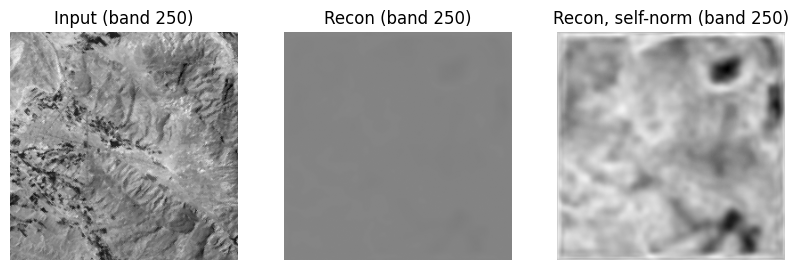

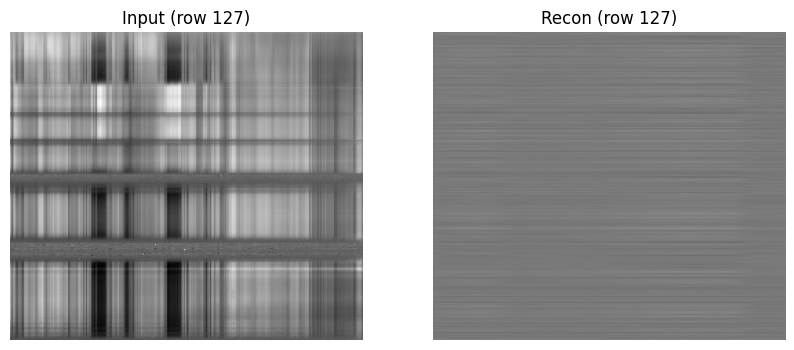

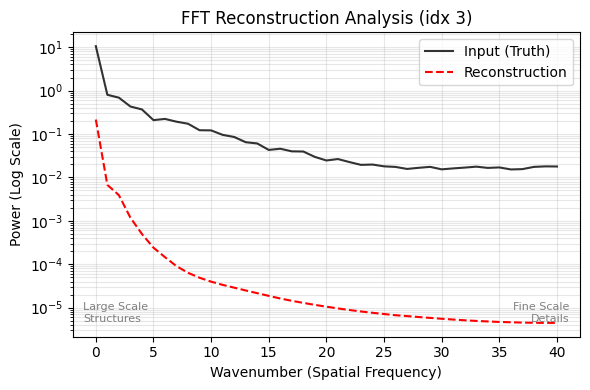

epoch 000 val_loss 3.020128
-----------------------------------
Val Classification Accuracy: 47.19%
      | Pred P | Pred N |
True P| 31     | 12     |
True N| 35     | 11     |
F1: 56.88% | Precision: 46.97% | Recall: 72.09%
-----------------------------------
saved best checkpoint: /more_data/models/v4.1/hs_autoencoder_best_v4.0_ps16x16x15_overlapTrue_True_overNoneqx1024d_20260220_060154_1e-06-1e-08_val_loss_3.020128_totalepochs_0.pt

Component    | Raw Avg    | Weight   | Weighted   | % Total
-----------------------------------------------------------------
l_mse        | 0.750058   | 1        | 0.750058   |   24.8%
l_deriv      | 0.022784   | 2        | 0.045568   |    1.5%
l_sam        | 1.232933   | 0.05     | 0.061647   |    2.0%
l_spatial    | 0.054229   | 5        | 0.271143   |    9.0%
l_ortho      | 0.000000   | 0        | 0.000000   |    0.0%
l_fft        | 0.295559   | 1.5      | 0.443339   |   14.7%
l_class      | 0.965582   | 1.5      | 1.448373   |   48.0%
-------------

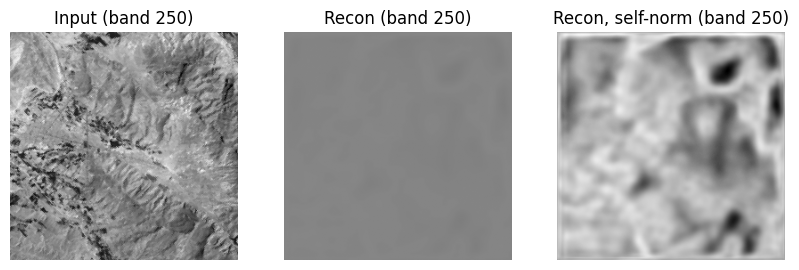

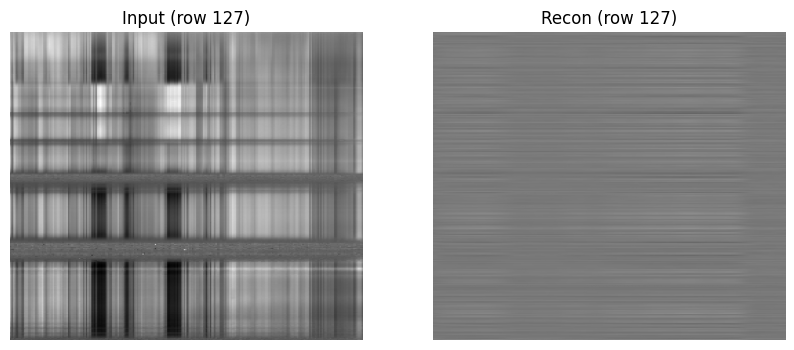

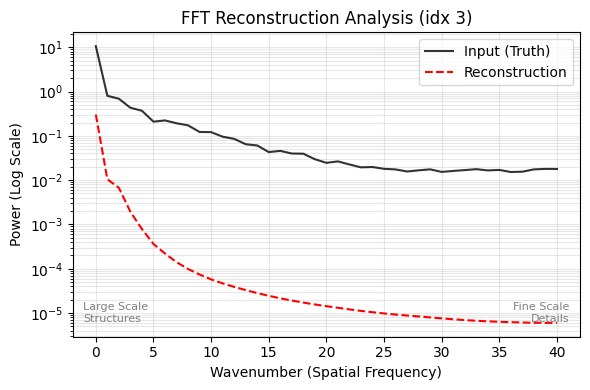

epoch 001 val_loss 5.629835
-----------------------------------
Val Classification Accuracy: 49.44%
      | Pred P | Pred N |
True P| 15     | 28     |
True N| 17     | 29     |
F1: 40.00% | Precision: 46.87% | Recall: 34.88%
-----------------------------------

Component    | Raw Avg    | Weight   | Weighted   | % Total
-----------------------------------------------------------------
l_mse        | 0.740362   | 1        | 0.740362   |   13.2%
l_deriv      | 0.022846   | 2        | 0.045692   |    0.8%
l_sam        | 1.163387   | 0.05     | 0.058169   |    1.0%
l_spatial    | 0.054222   | 5        | 0.271111   |    4.8%
l_ortho      | 0.000000   | 0        | 0.000000   |    0.0%
l_fft        | 0.295382   | 1.5      | 0.443074   |    7.9%
l_class      | 2.714285   | 1.5      | 4.071428   |   72.3%
-----------------------------------------------------------------
TOTAL        | -          | -        | 5.629835   |  100.0%

------------------------------
Epoch 1 Timing Stats:
  Total Wal

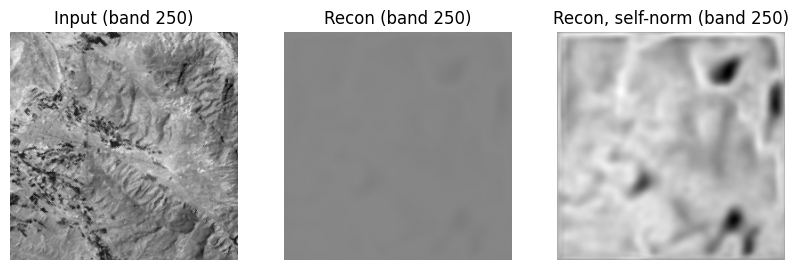

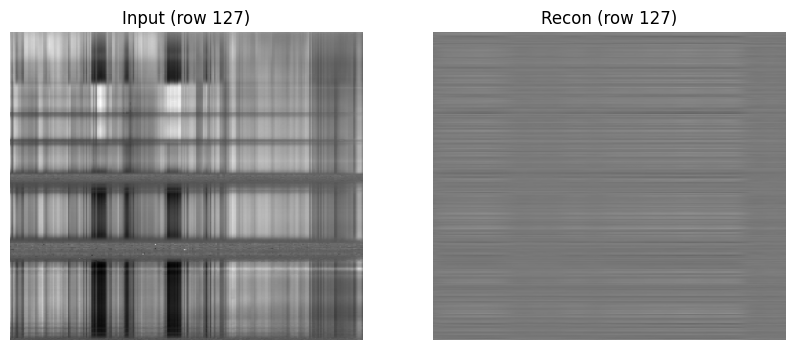

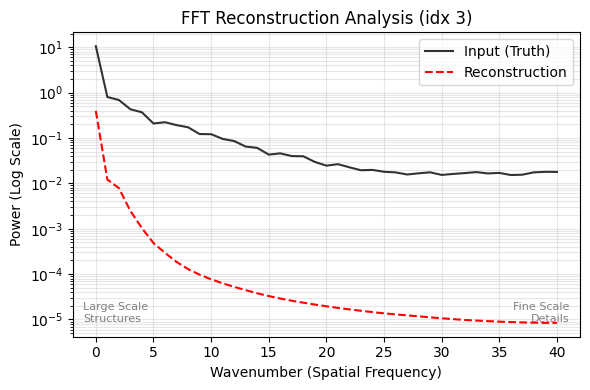

epoch 002 val_loss 3.446808
-----------------------------------
Val Classification Accuracy: 52.81%
      | Pred P | Pred N |
True P| 1      | 42     |
True N| 0      | 46     |
F1: 4.55% | Precision: 100.00% | Recall: 2.33%
-----------------------------------

Component    | Raw Avg    | Weight   | Weighted   | % Total
-----------------------------------------------------------------
l_mse        | 0.725888   | 1        | 0.725888   |   21.1%
l_deriv      | 0.023909   | 2        | 0.047818   |    1.4%
l_sam        | 1.093626   | 0.05     | 0.054681   |    1.6%
l_spatial    | 0.054213   | 5        | 0.271063   |    7.9%
l_ortho      | 0.000000   | 0        | 0.000000   |    0.0%
l_fft        | 0.295006   | 1.5      | 0.442509   |   12.8%
l_class      | 1.269899   | 1.5      | 1.904848   |   55.3%
-----------------------------------------------------------------
TOTAL        | -          | -        | 3.446808   |  100.0%

------------------------------
Epoch 2 Timing Stats:
  Total Wall

In [ ]:
# Timing variables
flag_do_timing = True



# GPU timers (for compute)
# We create reusable events to minimize overhead
start_fwd = torch.cuda.Event(enable_timing=True)
end_fwd   = torch.cuda.Event(enable_timing=True)
start_bwd = torch.cuda.Event(enable_timing=True)
end_bwd   = torch.cuda.Event(enable_timing=True)
start_loss= torch.cuda.Event(enable_timing=True)
end_loss  = torch.cuda.Event(enable_timing=True)

# Push normalization constants to GPU
band_mean_t = torch.tensor(band_mean, device="cuda").view(-1,1,1)
band_std_t  = torch.tensor(band_std,  device="cuda").view(-1,1,1)

smoothed_loss = -1.0
for epoch in range(num_epochs): # Epoch Loop
    
    total_epoch_time = 0.0
    total_data_load_time = 0.0

    total_forward_time = 0.0
    total_backward_time = 0.0
    total_loss_calc_time = 0.0

    total_val_time = 0.0
    total_save_time = 0.0
    total_display_time = 0.0

    t_epoch_start = time.time()
    model.train()
    
    t_data_load_start = time.time()
    for batch_idx, (x, valid, labels) in enumerate(train_dl): # Batch Loop
        if batch_idx >= batches_per_epoch:
            break # Conclude epoch
        total_data_load_time += time.time() - t_data_load_start
        
        
        x = x.to(device, non_blocking=True).float()
        valid = valid.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        opt.zero_grad(set_to_none=True)
        loss_total = 0.0
        
        # Choose random rotation and flip, short circuit manual augmentation loop.  TODO: Refactor
        do_flip_selected = [random.choice((False, True))]
        rot_amount_selected = [random.choice((0, 1, 2, 3))]
        
        did_flip = False
        for do_flip in do_flip_selected:
            if do_flip and not did_flip:
                did_flip = True
                x = torch.flip(x, dims=(-1,))
                valid = torch.flip(valid, dims=(-1,))
                
            for rot_amount in rot_amount_selected:
                ## Forward Pass
                if flag_do_timing: start_fwd.record()
                with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                    #print(x.shape)# Saves memory on a case-by-case basis inside torch
                    x_hat, class_logits = model(x)
                    #print("foo")
                
                
                if flag_do_timing: 
                    end_fwd.record()
                    torch.cuda.synchronize()
                    total_forward_time += start_fwd.elapsed_time(end_fwd)
                
                
                ## Calculate loss
                if flag_do_timing: start_loss.record()
                loss_r = recon_loss(x_hat.float(), x.float(), valid, 
                                  alpha=l_alpha, beta=l_beta, gamma=l_gamma, delta=l_delta, theta=l_theta, 
                                  wn_start=loss_fft_wavenum_start, wn_end=loss_fft_wavenum_end)# / 8.0 #average over 8 augmentations
                
                loss_c = class_loss(class_logits, labels)
                loss = loss_r + (l_class * loss_c)
                
                if flag_do_timing: 
                    end_loss.record()
                    torch.cuda.synchronize()
                    total_loss_calc_time += start_loss.elapsed_time(end_loss)
                
                
                ## Backward Pass
                if flag_do_timing: start_bwd.record()
                loss.backward()
                
                if flag_do_timing: 
                    end_bwd.record()
                    torch.cuda.synchronize()
                    total_backward_time += start_bwd.elapsed_time(end_bwd)
                
                loss_total += loss#.item() / 8.0
                
                x = torch.rot90(x, k=1, dims=(-2, -1))
                valid = torch.rot90(valid, k=1, dims=(-2, -1))

        
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step()

        if smoothed_loss == -1.0: smoothed_loss = loss_total
        smoothed_loss = smoothed_loss * 0.9 + loss_total * 0.1
        if batch_idx % (max(1, batches_per_epoch//8)) == 0:
            time_elapsed = time.time() - t_epoch_start
            estimate_time_to_completion = (time_elapsed / (batch_idx + 1)) * (batches_per_epoch - batch_idx - 1)
            print(
                f"epoch {epoch:03d} batch {batch_idx:05d} of {batches_per_epoch} "
                f"train_loss {loss_total:.6f} smoothed_loss {smoothed_loss:.6f} "
                f"lr {sched.get_last_lr()[0]:.2e} "
                f"time elapsed {time_elapsed:.0f}s "
                f"ETA {estimate_time_to_completion:.0f}s"
            )
            
        t_data_load_start = time.time()
        
    # validation
    t_val_start = time.time()
    model.eval()
    val_losses = []
    loss_components_list = []
    
    val_tp_total = 0
    val_fp_total = 0
    val_tn_total = 0
    val_fn_total = 0
    val_accuracy_list = []
    
    with torch.no_grad():
        for batch_idx, (x, valid, labels) in enumerate(val_dl):
            if batch_idx >= batches_per_val:
                break # Conclude epoch
            
            x = x.to(device, non_blocking=True).float()
            valid = valid.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                x_hat, class_logits = model(x)

            loss_r, loss_components = recon_loss(x_hat.float(), x.float(), valid, verbose=False, 
                                  alpha=l_alpha, beta=l_beta, gamma=l_gamma, delta=l_delta, theta=l_theta, return_components=True, 
                                  wn_start=loss_fft_wavenum_start, wn_end=loss_fft_wavenum_end)
            loss_c = class_loss(class_logits, labels)
            loss = loss_r + (l_class * loss_c)
            val_losses.append(loss.item())
            
            accuracy, val_tp, val_fp, val_tn, val_fn = do_classification(class_logits, labels)
            val_tp_total += val_tp
            val_fp_total += val_fp
            val_tn_total += val_tn
            val_fn_total += val_fn
            val_accuracy_list.append(accuracy)
            
            loss_components_cpu = {
                k: v.detach().float().cpu().item() if torch.is_tensor(v) else float(v)
                for k, v in loss_components.items()
            }
            loss_components_cpu['l_class'] = loss_c.item()
            loss_components_list.append(loss_components_cpu)
            
            if batch_idx % (max(1, batches_per_epoch//4)) == 0:
                print(f"validation batch {batch_idx:05d} of {batches_per_val}")
    
    total_val_time += time.time() - t_val_start
    
    t_display_start = time.time()
    show_recon_band(val_ds, model, idx=3, band=250, device="cuda:0")
    show_recon_slice(val_ds, model, idx=3, row=127, device="cuda:0")
    show_fft_comparison(val_ds, model, idx=3, device="cuda:0")
    # show_recon_band(train_ds, model, idx=0, band=241, device="cuda:0")
    # show_recon_slice(train_ds, model, idx=0, row=127, device="cuda:0")
    
    total_display_time += time.time() - t_display_start
    
    val_loss = float(np.mean(val_losses))
    print(f"epoch {epoch:03d} val_loss {val_loss:.6f}")
    
    val_accuracy = float(np.mean(val_accuracy_list))
    val_recall = val_tp_total/(val_tp_total+val_fn_total+1e-6)
    val_precision = val_tp_total/(val_tp_total+val_fp_total+1e-6)
    val_f1 = 2*val_precision*val_recall/(val_precision+val_recall+1e-6)
    
    print("-" * 35)
    print(f"Val Classification Accuracy: {val_accuracy:.2%}")
    print(f"      | Pred P | Pred N |")
    # ANSI color codes: green = \033[92m, red = \033[91m, reset = \033[0m
    print(f"True P| \033[92m{int(val_tp_total):<6}\033[0m | \033[91m{int(val_fn_total):<6}\033[0m |")
    print(f"True N| \033[91m{int(val_fp_total):<6}\033[0m | \033[92m{int(val_tn_total):<6}\033[0m |")
    print(f"F1: {val_f1:.2%} | Precision: {val_precision:.2%} | Recall: {val_recall:.2%}")
    print("-" * 35)

    t_save_start = time.time()

    # --- always save a "latest" resume checkpoint ---
    model_to_save = model
    if hasattr(model, '_orig_mod'):
        model_to_save = model._orig_mod
        
    checkpoint = {
            "model_state_dict": model_to_save.state_dict(),
            "opt_state_dict": opt.state_dict(),
            "sched_state_dict": sched.state_dict(),
            "best_val": best_val,
            "epoch": epoch + starting_epoch,
            "step": 0,   # no longer used
            "band_mean": band_mean,
            "band_std": band_std,
            "patch_size_spatial": patch_size_spatial,
            "patch_size_spectral": patch_size_spectral,
            "decoder_input_channels": decoder_input_channels,
            "num_spectral_queries": num_spectral_queries,
            "hidden_size": hidden_size,
            "depth": depth,
            "num_heads": num_heads,
            "mlp_ratio": mlp_ratio,
        }
    
    
    torch.save(checkpoint, "hs_autoencoder_latest.pt")
    total_save_time += time.time() - t_save_start
    
    # --- save best to model_save_path ---
    if val_loss < best_val:
        best_val = val_loss
        best_model_save_path = model_save_path
        append_string = f"val_loss_{val_loss:.6f}_totalepochs_{epoch + starting_epoch}"
        best_model_save_path = best_model_save_path.replace(".pt", f"_{append_string}.pt")
        torch.save(checkpoint, best_model_save_path)
        print(f"saved best checkpoint: {best_model_save_path}")
        
    #Print Loss Components Breakdown:
    loss_components_avg = {k: np.mean([d[k] for d in loss_components_list]) for k in loss_components_list[0]}
        
    # 2. Define the weights map (Make sure these match your variable names!)
    #    Note: 'l_mse' usually has a weight of 1.0 implicitly if not defined
    loss_weights = {
        'l_mse':     1.0,
        'l_deriv':   l_alpha,  # Matches alpha
        'l_spatial': l_beta,   # Matches beta
        'l_sam':     l_gamma,  # Matches gamma
        'l_ortho':   l_delta,  # Matches delta
        'l_fft':     l_theta,  # Matches theta
        'l_class':   l_class   # Binary Plume Classifier Weight
    }
    
    # 3. Calculate Totals for Percentage
    total_weighted_loss = sum(avg * loss_weights.get(k, 1.0) for k, avg in loss_components_avg.items())
    
    # 4. Print Table
    print("\n" + "="*65)
    print(f"{'Component':<12} | {'Raw Avg':<10} | {'Weight':<8} | {'Weighted':<10} | {'% Total':<7}")
    print("-" * 65)
    
    for k, raw_val in loss_components_avg.items():
        weight = loss_weights.get(k, 1.0) # Default to 1.0 if not found
        weighted_val = raw_val * weight
        pct = (weighted_val / total_weighted_loss) * 100 if total_weighted_loss > 0 else 0.0
        
        print(f"{k:<12} | {raw_val:<10.6f} | {weight:<8.4g} | {weighted_val:<10.6f} | {pct:>6.1f}%")
    print("-" * 65)
    print(f"{'TOTAL':<12} | {'-':<10} | {'-':<8} | {total_weighted_loss:<10.6f} | {'100.0':>6}%")
    print("="*65 + "\n")
    
    
    
    # Calculate totals
    total_epoch_time = time.time() - t_epoch_start
    
    print("-" * 30)
    print(f"Epoch {epoch} Timing Stats:")
    print(f"  Total Wall Time:  {total_epoch_time:.2f}s")
    print(f"  Data Loading:     {total_data_load_time:.2f}s")
    if flag_do_timing: print(f"  GPU Forward:      {total_forward_time/1000.:.2f}s")
    if flag_do_timing: print(f"  GPU Backward:     {total_backward_time/1000.:.2f}s")
    if flag_do_timing: print(f"  Loss Calc:        {total_loss_calc_time/1000.:.2f}s")
    print(f"  Validation:       {total_val_time:.2f}s")
    print(f"  Display:          {total_display_time:.2f}s")
    print(f"  Save:             {total_save_time:.2f}s")
    print("-" * 30)
    
    # Reset accumulators for next epoch
    total_data_load_time = 0.0
    total_forward_time = 0.0
    total_backward_time = 0.0
    total_loss_calc_time = 0.0
    total_val_time = 0.0
    total_save_time = 0.0
    total_display_time = 0.0



### Stats with 8x manual augmentation, with hypercubes on /root/emit_data/
# ------------------------------
# Epoch 0 Timing Stats:
#   Total Wall Time:  240.91s
#   Data Loading:     5.87s
#   GPU Forward:      56.80s
#   GPU Backward:     152.49s
#   Loss Calc:        2.82s
# ------------------------------


### Stats with 1x random augmentation, with hypercubes on /root/emit_data/
# ------------------------------
# Epoch 0 Timing Stats:
#   Total Wall Time:  49.24s
#   Data Loading:     5.57s
#   GPU Forward:      7.08s
#   GPU Backward:     18.90s
#   Loss Calc:        0.39s
# ------------------------------


### Stats with 1x random augmentation, with hypercubes on /root/emit_data/, with timing disabled:
# ------------------------------
# Epoch 0 Timing Stats:
#   Total Wall Time:  53.05s
#   Data Loading:     5.64s
# ------------------------------


### With added compilation:
#------------------------------
# Epoch 0 Timing Stats:
#   Model Compile:    0.00s
#   Total Wall Time:  45.43s
#   Data Loading:     5.27s
#   GPU Forward:      6.50s
#   GPU Backward:     16.62s
#   Loss Calc:        0.34s
#   Validation:       11.55s
#   Display:          0.78s
#   Save:             3.05s
# ------------------------------

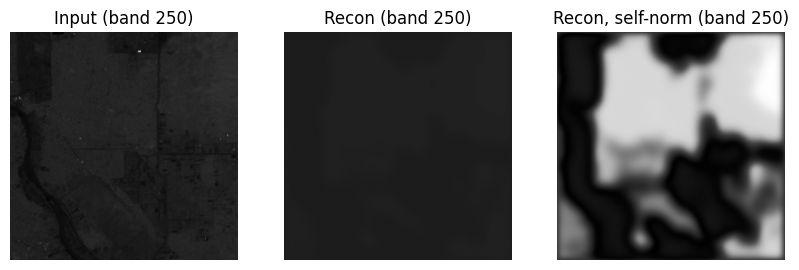

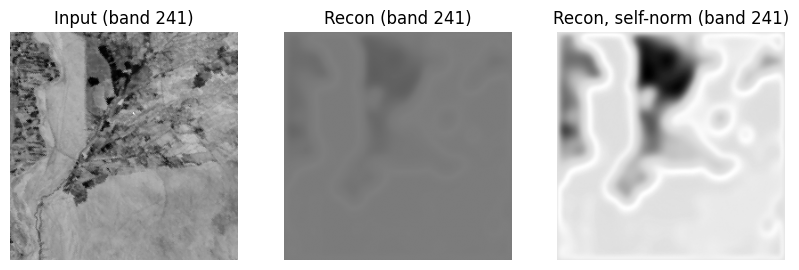

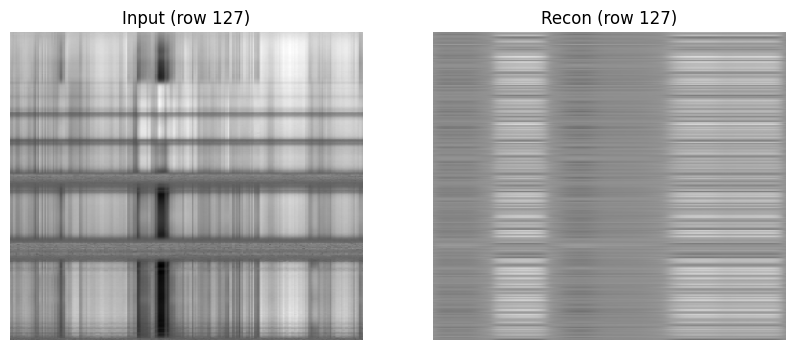

In [ ]:
show_recon_band(val_ds, model, idx=2, band=250, device="cuda:0")
show_recon_band(train_ds, model, idx=0, band=241, device="cuda:0")
show_recon_slice(train_ds, model, idx=0, row=127, device="cuda:0")

In [ ]:
print(type(model))
print(model)

<class 'torch._dynamo.eval_frame.OptimizedModule'>
OptimizedModule(
  (_orig_mod): HyperspectralAutoencoder(
    (hsi_encoder): HyperspectralVisionEncoder(
      (patch_embed): Conv3d(1, 2048, kernel_size=(15, 16, 16), stride=(7, 8, 8), padding=(0, 4, 4))
      (transformer_blocks): ModuleList(
        (0-5): 6 x SimpleTransformerBlock(
          (pre_attn_norm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=2048, out_features=2048, bias=True)
          )
          (pre_mlp_norm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (0): Linear(in_features=2048, out_features=4096, bias=True)
            (1): GELU(approximate='none')
            (2): Linear(in_features=4096, out_features=2048, bias=True)
          )
        )
      )
      (final_norm): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    )
    (decoder_

In [ ]:
import torch
import torch.nn as nn

def param_bytes_by_module(model: nn.Module, topk=30):
    rows = []
    for name, module in model.named_modules():
        # only count params owned by this module (not children) to avoid double counting
        pbytes = 0
        for p in module.parameters(recurse=False):
            pbytes += p.numel() * p.element_size()
        if pbytes > 0:
            rows.append((pbytes, name, module.__class__.__name__))
    rows.sort(reverse=True, key=lambda x: x[0])
    print("Top parameter owners:")
    for b, name, cls in rows[:topk]:
        print(f"{b/1024**2:8.1f} MB  {name:<40}  {cls}")
    total = sum(b for b, _, _ in rows)
    print(f"Total (counting only direct params per module): {total/1024**2:.1f} MB")

# usage:
target = model.module if isinstance(model, nn.DataParallel) else model
param_bytes_by_module(target, topk=40)

Top parameter owners:
   312.0 MB  _orig_mod.decoder_projector.0             Linear
    48.0 MB  _orig_mod.hsi_encoder.transformer_blocks.0.self_attn  MultiheadAttention
    48.0 MB  _orig_mod.hsi_encoder.transformer_blocks.1.self_attn  MultiheadAttention
    48.0 MB  _orig_mod.hsi_encoder.transformer_blocks.2.self_attn  MultiheadAttention
    48.0 MB  _orig_mod.hsi_encoder.transformer_blocks.3.self_attn  MultiheadAttention
    48.0 MB  _orig_mod.hsi_encoder.transformer_blocks.4.self_attn  MultiheadAttention
    48.0 MB  _orig_mod.hsi_encoder.transformer_blocks.5.self_attn  MultiheadAttention
    32.0 MB  _orig_mod.hsi_encoder.transformer_blocks.0.mlp.0  Linear
    32.0 MB  _orig_mod.hsi_encoder.transformer_blocks.1.mlp.0  Linear
    32.0 MB  _orig_mod.hsi_encoder.transformer_blocks.2.mlp.0  Linear
    32.0 MB  _orig_mod.hsi_encoder.transformer_blocks.3.mlp.0  Linear
    32.0 MB  _orig_mod.hsi_encoder.transformer_blocks.4.mlp.0  Linear
    32.0 MB  _orig_mod.hsi_encoder.transformer_blo

In [ ]:
import torch
import torch.nn as nn

def activation_peak_by_module(model: nn.Module, example_input: torch.Tensor, use_autocast=True, topk=30):
    device = example_input.device
    torch.cuda.reset_peak_memory_stats(device)
    torch.cuda.synchronize(device)

    peaks = []
    hooks = []

    def pre_hook(name):
        def _pre(module, inputs):
            torch.cuda.synchronize(device)
            module._mem_before = torch.cuda.memory_allocated(device)
        return _pre

    def post_hook(name):
        def _post(module, inputs, output):
            torch.cuda.synchronize(device)
            after = torch.cuda.memory_allocated(device)
            before = getattr(module, "_mem_before", after)
            delta = after - before
            peaks.append((delta, name, module.__class__.__name__))
        return _post

    # Attach hooks to “leaf” modules only (actual ops)
    for name, m in model.named_modules():
        if len(list(m.children())) == 0:
            hooks.append(m.register_forward_pre_hook(pre_hook(name)))
            hooks.append(m.register_forward_hook(post_hook(name)))

    model.eval()
    with torch.no_grad():
        if use_autocast:
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                _ = model(example_input)
        else:
            _ = model(example_input)

    for h in hooks:
        h.remove()

    peaks.sort(reverse=True, key=lambda x: x[0])
    print("Top activation deltas during forward (approx):")
    for d, name, cls in peaks[:topk]:
        print(f"{d/1024**2:8.1f} MB  {name:<50}  {cls}")

    torch.cuda.synchronize(device)
    print("Peak memory allocated:", torch.cuda.max_memory_allocated(device)/1024**2, "MB")

# usage:
target = model.module if isinstance(model, nn.DataParallel) else model
x, valid = next(iter(train_dl))
x = x.cuda().float()
activation_peak_by_module(target, x, use_autocast=True, topk=40)

ValueError: too many values to unpack (expected 2)

In [ ]:
# import torch, types

# def report_cuda_objects(topk=30):
#     items = []
#     g = globals()

#     # CUDA tensors
#     for name, obj in g.items():
#         if isinstance(obj, torch.Tensor) and obj.is_cuda:
#             items.append((obj.numel() * obj.element_size(), name, type(obj).__name__, tuple(obj.shape)))

#     # CUDA modules (count their parameter bytes)
#     for name, obj in g.items():
#         if isinstance(obj, torch.nn.Module):
#             nbytes = 0
#             on_cuda = False
#             for p in obj.parameters(recurse=True):
#                 if p.is_cuda:
#                     on_cuda = True
#                     nbytes += p.numel() * p.element_size()
#             for b in obj.buffers(recurse=True):
#                 if b.is_cuda:
#                     on_cuda = True
#                     nbytes += b.numel() * b.element_size()
#             if on_cuda and nbytes > 0:
#                 items.append((nbytes, name, type(obj).__name__, ("module_params",)))

#     items.sort(reverse=True, key=lambda x: x[0])
#     print("torch.cuda.memory_allocated():", torch.cuda.memory_allocated())
#     print("top CUDA residents:")
#     for nbytes, name, typ, shape in items[:topk]:
#         print(f"  {nbytes/1024**2:8.1f} MB  {name:<20}  {typ:<30}  {shape}")

# report_cuda_objects()

In [ ]:
# # clear cuda memory:
# for name in ["dual", "qwen", "processor", "rgb_inputs", "pixel_values", "pixel_values_hs", "tok",
#              "x", "valid", "x_hat", "opt", "sched"]:
#     if name in globals():
#         del globals()[name]
# gc.collect()
# torch.cuda.empty_cache()
# torch.cuda.memory_allocated()


In [ ]:
# ## Old Implementation, not used:
# class SimpleTransformerBlock(nn.Module):  # minimal Transformer encoder block
#     def __init__(self, d, n_heads=8, mlp_ratio=4.0, dropout=0.0):  # configure width/heads/MLP
#         super().__init__()  # initialize nn.Module base
#         self.ln1 = nn.LayerNorm(d)  # pre-norm before attention
#         self.attn = nn.MultiheadAttention(d, n_heads, dropout=dropout, batch_first=True)  # self-attention over tokens
#         self.ln2 = nn.LayerNorm(d)  # pre-norm before MLP
#         self.mlp = nn.Sequential(  # token-wise feedforward network
#             nn.Linear(d, int(d * mlp_ratio)),  # expand hidden dim
#             nn.GELU(),  # nonlinearity
#             nn.Linear(int(d * mlp_ratio), d),  # project back to hidden dim
#         )  # end MLP

#     def forward(self, x):  # run one block
#         # x: (B, N, d)  # B=batch, N=tokens, d=hidden size
#         y = self.ln1(x)  # normalize for stable attention
#         y, _ = self.attn(y, y, y, need_weights=False)  # self-attend (query=key=value=tokens)
#         x = x + y  # residual connection after attention
#         x = x + self.mlp(self.ln2(x))  # residual connection after MLP
#         return x  # output tokens

# class HyperspectralVisionEncoder(nn.Module):  # Qwen3-VL-compatible vision module
#     """
#     Qwen3-VL-compatible vision module:  # what this is for
#       forward(pixel_values, grid_thw=...) -> (embeds, deepstack_list)  # required return structure
#     """  # end docstring
#     def __init__(self, hidden_size, in_ch=285, patch=16, spatial_merge_size=2, depth=6, n_heads=8):  # set model hyperparams
#         super().__init__()  # initialize nn.Module base
#         self.hidden_size = hidden_size  # token embedding dimension (must match Qwen text hidden size)
#         self.patch = patch  # patch size in pixels (e.g., 16)
#         self.spatial_merge_size = spatial_merge_size  # required attr: Qwen expects this to compute token counts
#         self.patch_embed = nn.Conv2d(in_ch, hidden_size, kernel_size=patch, stride=patch)  # patchify + project 285 bands -> hidden_size

#         # learned pos embed for 16x16 grid (you can generalize if needed)  # positional encoding note
#         self.pos = nn.Parameter(torch.zeros(1, (256 // patch) * (256 // patch), hidden_size))  # (1, Hp*Wp, hidden_size) learnable positions
#         nn.init.normal_(self.pos, std=0.02)  # standard init for transformer embeddings

#         self.blocks = nn.ModuleList([SimpleTransformerBlock(hidden_size, n_heads=n_heads) for _ in range(depth)])  # stack of transformer blocks
#         self.ln = nn.LayerNorm(hidden_size)  # final normalization

#     def _merge_2x2(self, x, H, W):  # spatial token merge (reduces token count)
#         # x: (B, H*W, d) -> (B, (H/2)*(W/2), d)  # shape transform summary
#         m = self.spatial_merge_size  # merge factor (e.g., 2)
#         assert H % m == 0 and W % m == 0  # ensure merge divides grid
#         B, _, d = x.shape  # unpack shapes
#         x = x.view(B, H, W, d)  # reshape tokens back to 2D grid
#         x = x.view(B, H // m, m, W // m, m, d).mean(dim=(2, 4))  # average pool each m×m block into one token
#         x = x.reshape(B, (H // m) * (W // m), d)  # flatten merged grid back to sequence
#         return x  # return merged tokens

#     def forward(self, pixel_values, grid_thw=None, **kwargs):  # main forward used by Qwen
#         # pixel_values: (N, C=285, H=256, W=256)  # expected input tensor
#         # grid_thw: (num_images, 3) where each row is [t, h_grid, w_grid] in PATCH GRID units.  # expected grid metadata
#         x = self.patch_embed(pixel_values.to(dtype=self.patch_embed.weight.dtype))
#         B, d, Hp, Wp = x.shape  # Hp/Wp are patch-grid height/width
#         x = x.flatten(2).transpose(1, 2)  # (B, d, Hp*Wp)->(B, Hp*Wp, d) tokens

#         # if you always use 256x256, this is fine; otherwise you’ll want interpolated pos embeddings  # caveat
#         x = x + self.pos[:, : x.shape[1], :]  # add learned positional embedding per token

#         for blk in self.blocks:  # iterate transformer layers
#             x = blk(x)  # update token sequence
#         x = self.ln(x)  # final norm on tokens

#         x = self._merge_2x2(x, Hp, Wp)  # reduce tokens via spatial merge (e.g., 256 -> 64 tokens)

#         # Qwen expects flattened tokens across images in the batch for scattering  # Qwen integration detail
#         x = x.reshape(-1, d)  # (B, tokens, d)->(B*tokens, d) for masked_scatter
#         deepstack = []  # optional deepstack features; empty means “don’t use deepstack”
#         return x, deepstack  # (image_embeds, deepstack_embeds)

# class HyperspectralAutoencoder(nn.Module):  # wrapper that adds a decoder for reconstruction pretraining
#     def __init__(self, hidden_size, in_ch=285, patch=16, spatial_merge_size=2, depth=6, n_heads=8):  # configure AE
#         super().__init__()  # initialize nn.Module base
#         self.enc = HyperspectralVisionEncoder(hidden_size, in_ch, patch, spatial_merge_size, depth, n_heads)  # encoder = future Qwen vision tower
#         self.hidden_size = hidden_size  # store hidden size for reshapes
#         self.patch = patch  # store patch size
#         self.spatial_merge_size = spatial_merge_size  # store merge size
#         self.unmerge_proj = nn.Linear(hidden_size, hidden_size)  # lightweight decoder “prep” projection

#         # simple decoder: un-merge by repeating tokens and deconvolving  # decoder approach
#         self.dec_deconv = nn.ConvTranspose2d(hidden_size, in_ch, kernel_size=patch, stride=patch)  # map patch-grid features back to 285-band image

#     def forward(self, x):  # reconstruct input cube
#         # x: (B, 285, 256, 256)  # expected hyperspectral chip
#         B = x.shape[0]  # batch size
#         # encoder returns (B*tokens, hidden)  # encoder output format note
#         z, _ = self.enc(x, grid_thw=None)  # encode into tokens (ignore deepstack)
#         tokens_per_img = z.shape[0] // B  # infer tokens per image (assumes fixed token count per sample)
#         z = z.view(B, tokens_per_img, self.hidden_size)  # reshape flattened tokens back to (B, tokens, d)

#         # un-merge (inverse of 2x2 mean merge): just repeat 4x (simple baseline)  # approximate inverse
#         m = self.spatial_merge_size  # merge factor
#         z = self.unmerge_proj(z)  # small decoder projection
#         z = z.unsqueeze(2).repeat(1, 1, m * m, 1).reshape(B, tokens_per_img * m * m, self.hidden_size)  # expand tokens to undo merge count

#         # back to patch grid  # reshape tokens into 2D feature map
#         Hp = 256 // self.patch  # patch-grid height (e.g., 16)
#         Wp = 256 // self.patch  # patch-grid width (e.g., 16)
#         z = z.transpose(1, 2).reshape(B, self.hidden_size, Hp, Wp)  # (B, tokens, d)->(B, d, Hp, Wp)

#         x_hat = self.dec_deconv(z)  # decode to reconstructed hyperspectral cube
#         return x_hat  # reconstructed output

In [ ]:
# ## Original Training Code - no training only no validation, sanity check.
# # 1) pick hidden size from Qwen config (so encoder is drop-in later)
# qwen_name = "Qwen/Qwen3-VL-2B-Instruct"
# cfg = AutoConfig.from_pretrained(qwen_name)
# hidden_size = cfg.text_config.hidden_size
# print("Qwen hidden_size:", hidden_size)

# # 2) build model (uses the classes you already pasted earlier)
# model = HyperspectralAutoencoder(hidden_size=hidden_size, in_ch=285, patch=16, spatial_merge_size=2, depth=6, n_heads=8)
# model = model.cuda()

# # 3) data
# train_ds = EmitRadDataset(rad_files, band_mean, band_std, fill=FILL)
# train_dl = DataLoader(
#     train_ds,
#     batch_size=4,
#     shuffle=True,
#     num_workers=0,    
#     pin_memory=False,    
# )
# # 4) optimizer + (optional) AMP
# opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
# scaler = torch.cuda.amp.GradScaler(enabled=False)  # set True if using fp16; for bf16 use autocast without GradScaler

# model.train()
# for step, (x, valid) in enumerate(train_dl):
#     x = x.cuda(non_blocking=True)
#     valid = valid.cuda(non_blocking=True)

#     opt.zero_grad(set_to_none=True)
#     with torch.cuda.amp.autocast(dtype=torch.bfloat16):  # or remove autocast to keep everything float32
#         x_hat = model(x)
#         loss = masked_mse(x_hat, x, valid)

#     loss.backward()
#     opt.step()

#     if step % 5 == 0:
#         print(f"step {step:05d}  loss {loss.item():.6f}")
#     if step == 500:  # quick sanity run; increase later
#         break